## CARD: Training Session 5

### Species transport inside a catalyst pellet

#### Example: Pellet with first order reaction

![pellet](./figures/session_5/example1.svg)

**Species conservation**:

$ \boxed{ \varepsilon \frac{d c_A}{d t} = \frac{D_i}{r^n R^2} \frac{\delta}{\delta r} \left( r^n \frac{\delta c_A}{\delta r} \right) + k c_A \rho_{cat} (1 - \varepsilon) }$

|Variable|Description|Unit|
|---|---|---|
|$k$| rate constant | $𝑚^3 s^{−1}kg_{cat}^{−1}$ |
|$\varepsilon$| porosity | $-$ |
|$D_A$| molecular diffusion coefficient of component A | $m^2s^{−1}$|

**With the Boundary conditions**:

$ \boxed{ \left( \frac{\delta c_A}{\delta r} \right)_{r=0} = 0 } $

$ \boxed{ c_{A, r=0} = c_{A, \text{surf}} } $

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [1]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import i0


Define values of constant parameters:

In [2]:
D_A = 1e-5      # [m^2/s]
k = 0.001       # [m^3/s kg]
n = 2           # shape factor: plane: 0, cylinder: 1, sphere: 2
R = 10e-3       # [m]
rho_cat = 1000  # [kg/m^3]
eps = 0.5       # [-]

if n == 0:
    geometry = "plane"
elif n == 1:
    geometry = "cylinder"
elif n == 2:
    geometry = "sphere"

Now set the initial and boundary conditions:

In [3]:
c_A_surf = 10       # [mol/m^3]
c_A_0 = c_A_surf    # [mol/m^3]

Set the values and vector for the spatial discretization.
Define a vector with 𝑚 + 1 lines for $𝑟_{f,𝑗}$ and 𝑚 lines for $𝑟_{c,𝑗}$

In [4]:
n_rad = 200
delta_r = 1 / n_rad
r_c = np.arange(start=delta_r / 2, stop=1, step=delta_r)
r_f = np.linspace(0, 1, n_rad + 1)

Use an array as upper bound of the integral to calculate various timesteps:

In [5]:
t_0 = 0         # [s]
t_steps = 101   # [-]
t_end = 20      # [s]
t_i = np.linspace(t_0, t_end, t_steps)

Define necessary differential symbolic variables:

In [6]:
c_A = casADi.SX.sym("c_A", n_rad)

Define the species balance as ODE system with all control volumes (except the boundary volumes) using a for-loop:

In [7]:
ode = casADi.SX.sym("ode", n_rad)
for i in range(1, n_rad - 1):
    ode[i] = (
        D_A / (r_c[i] ** n * R**2 * eps * delta_r)
        * (
            r_f[i + 1] ** n * (c_A[i + 1] - c_A[i]) / delta_r
            - r_f[i] ** n * (c_A[i] - c_A[i - 1]) / delta_r
        )
        - k * c_A[i] * rho_cat * (1 - eps) / eps
    )

Define ODE at the boundary $r = 0$:

In [8]:
i = 0
ode[i] = (
    D_A / (r_c[i] ** n * R**2 * eps * delta_r)
    * (
        r_f[i + 1] ** n * (c_A[i + 1] - c_A[i]) / delta_r
        - r_f[i] ** n * (c_A[i] - c_A[i]) / delta_r
    )
    - k * c_A[i] * rho_cat * (1 - eps) / eps
)

Define ODE at the boundary $r = 1$:

In [9]:
i = n_rad - 1
ode[i] = (
    D_A / (r_c[i] ** n * R**2 * eps * delta_r)
    * (
        r_f[i + 1] ** n * (c_A_surf - c_A[i]) / (delta_r / 2)
        - r_f[i] ** n * (c_A[i] - c_A[i - 1]) / delta_r
    )
    - k * c_A[i] * rho_cat * (1 - eps) / eps
)

Next a casADi specific dictionary is created with the following entries:

In [10]:
dae = {"x": c_A, "ode": ode}

Then define and call the integrator to solve the DAE:

In [11]:
I = casADi.integrator("I", "idas", dae, t_0, t_i)
res_dic = I(x0=c_A_0)
c_A_res = res_dic["xf"].full()
c_A_res_norm = c_A_res / c_A_surf

Calculate the anatytical solution to compare the results:

In [12]:
thiele = np.sqrt(k * c_A_surf * rho_cat * (1 - eps) / (D_A * c_A_surf / (R) ** 2))
r_thiele = np.linspace(0, 1, 100)
if geometry == "plane":
    c_A_norm_analytical = np.cosh(thiele * r_thiele) / (np.cosh(thiele))
if geometry == "cylinder":
    c_A_norm_analytical = i0(thiele * r_thiele) / i0(thiele)
if geometry == "sphere":
    c_A_norm_analytical = np.sinh(thiele * r_thiele) / (np.sinh(thiele) * r_thiele)

C:\Users\Klaus\AppData\Local\Temp\ipykernel_6084\3757268802.py:8: RuntimeWarning: invalid value encountered in divide
  c_A_norm_analytical = np.sinh(thiele * r_thiele) / (np.sinh(thiele) * r_thiele)


Plot the results:

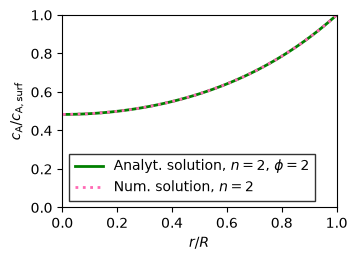

In [13]:
# Create figure and axes of plot
fig, ax = plt.subplots(figsize=(3.54, 2.5))

# Plot values
ax.plot(
    r_thiele,
    c_A_norm_analytical,
    color="green",
    linewidth=2,
    label=f"Analyt. solution, $n={n}$, $\\phi ={thiele:.0f}$",
)
ax.plot(
    r_c,
    c_A_res_norm[:, -1],
    color="hotpink",
    linestyle="dotted",
    linewidth=2,
    label=f"Num. solution, $n={n}$",
)

# Set axes parameters
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ax.set_xlabel("$r/R$")
ax.set_ylabel("$c_{\\mathregular{A}}/c_{\\mathregular{A,surf}}$")
ax.legend(fancybox=False, loc="best", ncol=1, edgecolor="black")